# Solving a Retirement Choice Model with FUES-EGM

**Paper**: Dobrescu and Shanker (2026), *A Fast Upper Envelope Scan Method for Discrete-Continuous Dynamic Programming*

This notebook solves the discrete retirement choice model from [Iskhakov et al. (2017)](https://onlinelibrary.wiley.com/doi/abs/10.3982/QE643) using the FUES upper envelope method. We proceed step by step:

1. **Model** — state the Bellman equation and Euler equations
2. **Load stages** — read the dolo-plus YAML stage declarations
3. **Solve** — run the canonical pipeline (`solve_nest`)
4. **Inspect EGM grids** — see the suboptimal points and how FUES removes them
5. **Comparison** — FUES vs DCEGM vs RFC vs CONSAV
6. **Scaling** — upper envelope time vs grid size

In [102]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import time, sys, os, yaml, tempfile
from pathlib import Path
from matplotlib import rcParams
from IPython.display import Image, display

# ── Repo paths ──
REPO = Path(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / 'src'))

SYNTAX_DIR = REPO / 'examples' / 'retirement' / 'syntax'
_tmpdir = tempfile.mkdtemp()

# ── Imports from the retirement example ──
from examples.retirement.solve import solve_nest
from examples.retirement.outputs import (
    get_policy, get_timing, get_solution_at_age,
    euler, consumption_deviation,
    plot_egrids, plot_cons_pol, plot_dcegm_cf,
)

# ── Plot style (Nord palette, matching MkDocs site theme) ──
NORD = {
    'frost':  ['#5e81ac', '#81a1c1', '#88c0d0', '#8fbcbb'],
    'aurora': ['#bf616a', '#d08770', '#ebcb8b', '#a3be8c', '#b48ead'],
    'fg':     '#2e3440',
    'bg':     '#ffffff',
    'grid':   '#d8dee9',
    'spine':  '#d8dee9',
}
METHOD_COLORS = {
    'FUES': NORD['frost'][0],   # blue
    'DCEGM': NORD['aurora'][1], # orange
    'RFC': NORD['aurora'][3],   # green
    'CONSAV': NORD['aurora'][4],# purple
}
METHOD_MARKERS = {'FUES': 'o', 'DCEGM': 's', 'RFC': '^', 'CONSAV': 'D'}

rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Source Sans Pro', 'Helvetica Neue', 'Arial'],
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.titleweight': '600',
    'axes.labelsize': 9,
    'figure.facecolor': NORD['bg'],
    'axes.facecolor': NORD['bg'],
    'axes.grid': True,
    'grid.alpha': 0.5,
    'grid.linewidth': 0.4,
    'grid.color': NORD['grid'],
    'axes.edgecolor': NORD['spine'],
    'axes.linewidth': 0.6,
    'text.color': NORD['fg'],
    'axes.labelcolor': NORD['fg'],
    'xtick.color': NORD['fg'],
    'ytick.color': NORD['fg'],
})

def style_ax(ax):
    """Apply Nord styling to axes."""
    for s in ax.spines.values():
        s.set_color(NORD['spine'])
        s.set_linewidth(0.6)
    ax.tick_params(colors=NORD['fg'], labelsize=8)

---

## 1. Model

An agent lives for $T$ periods. Each period they choose consumption $c_t$ and whether to work ($d_{t+1}=1$) or permanently retire ($d_{t+1}=0$). Working pays wage $y$ but costs utility $\delta$. Retirement is absorbing.

**Budget constraint:**

$$a_{t+1} = (1+r)a_t + d_t y - c_t$$

**Worker's Bellman equation** (for $d_t = 1$):

$$V_t^1(a) = \max_{c,\, d_{t+1} \in \{0,1\}} \Big\{ \log(c) - d_{t+1}\delta + \beta V_{t+1}^{d_{t+1}}(a') \Big\}$$

**Retiree's Bellman equation** (for $d_t = 0$):

$$V_t^0(a) = \max_c \Big\{ \log(c) + \beta V_t^0(a') \Big\}, \quad a' = (1+r)a - c$$

**Terminal condition:** $V_T^d(a) = \log((1+r)a + dy)$.

The key difficulty: $V_{t+1}^1$ is **not concave** because it is the upper envelope of concave functions, each conditional on a different sequence of future discrete choices.

In [103]:
# ── Display the stage YAML declarations ──
stage_names = ['work_cons', 'retire_cons', 'labour_mkt_decision']

for name in stage_names:
    path = SYNTAX_DIR / 'stages' / name / f'{name}.yaml'
    print(f'\n{"=" * 60}')
    print(f'  {name}  ({path.relative_to(REPO)})')
    print(f'{"=" * 60}')
    print(path.read_text())


  work_cons  (examples/retirement/syntax/stages/work_cons/work_cons.yaml)
name: WorkerConsumption

symbols:
  spaces:
    Xa: "@def R+"

  prestate:
    a: "@in Xa"           # assets (from branching stage)

  states:
    w: "@in Xa"           # cash-on-hand = (1+r)*a + y

  poststates:
    b: "@in Xa"           # end-of-period assets

  controls:
    c: "@in R+"

  exogenous: {}

  values:
    V[>]: "@in [-inf, inf)"
    V[<]: "@in [-inf, inf)"
    V: "@in [-inf, inf)"

  values_marginal:
    dV[>]: "@in R+"
    dV[<]: "@in R+"
    dV: "@in R+"

  parameters: [beta, r, y]

  settings: [n_w, w_min, w_max, m_bar]

equations:
  arvl_to_dcsn_transition: |
    w = (1 + r) * a + y

  dcsn_to_cntn_transition: |
    b = w - c

  cntn_to_dcsn_mover:
    Bellman: |
      V = max_c{log(c) + beta * V[>]}
    InvEuler: |
      c[>] = (beta * dV[>])^(-1)
    cntn_to_dcsn_transition: |
      w[>] = b + c[>]
    MarginalBellman: |
      dV = 1/c

  dcsn_to_arvl_mover:
    Bellman: |
      V[<] = V
 

## 2b. Calibration and settings (single source of truth)

These YAML files are consumed by the **calibrate** and **configure** functors of the dolo-plus pipeline. No parameters are hard-coded in Python.

In [104]:
# ── Display calibration and settings ──
for fname in ['calibration.yaml', 'settings.yaml']:
    path = SYNTAX_DIR / fname
    print(f'\n--- {fname} ---')
    print(path.read_text())


--- calibration.yaml ---
# Economic parameters (consumed by calibrate functor)
# Single source of truth — no Python-side defaults.
calibration:
  r: 0.02              # interest rate
  beta: 0.96           # discount factor
  delta: 1.5           # utility cost of working
  y: 20                # wage income for workers
  b: 1.0e-10           # borrowing constraint (near zero)
  smooth_sigma: 0      # logit smoothing (0 = hard max)


--- settings.yaml ---
# Numerical / structural settings (consumed by configure functor)
# Single source of truth — no Python-side defaults.
settings:
  # Lifecycle
  T: 20                  # number of periods

  # Asset grid (used by RetirementModel to construct arrival grid)
  grid_size: 3000        # number of asset grid points
  grid_max_A: 500        # upper bound for asset grid

  # Worker grids (work branch — used by dolo-plus configure)
  n_w: 300               # grid points for worker cash-on-hand
  w_min: 1.0e-10         # borrowing constraint (n

---

## 3. Solve via the Canonical Pipeline

`solve_nest` is the single entry point. It loads the YAML files, applies the three functors (methodize, configure, calibrate) to each stage, builds the model, and runs backward induction.

Each period solves three stages in reverse topological order:
1. **`retire_cons`** — retiree EGM (concave, no upper envelope needed)
2. **`work_cons`** — worker EGM + upper envelope (FUES/DCEGM/RFC/CONSAV)
3. **`labour_mkt_decision`** — $\max(V^{\text{work}}, V^{\text{retire}})$ pointwise

In [105]:
# ── Warmup (JIT compile) then timed solve ──
# Solve for 50 periods (longer horizon shows more kinks)
solve_nest(SYNTAX_DIR, method='FUES', config_overrides={'T': 50})

nest, model, stage_ops = solve_nest(
    SYNTAX_DIR, method='FUES', config_overrides={'T': 50})

print(f'Model: T={model.T}, grid_size={model.grid_size}, '
      f'beta={model.beta}, delta={model.delta}, y={model.y}')

ue_time, solve_time = get_timing(nest)
print(f'Euler error: {euler(model, get_policy(nest, "c")):.6f}')
print(f'UE time: {ue_time*1000:.2f}ms, Solve time: {solve_time*1000:.2f}ms')

Model: T=50, grid_size=3000, beta=0.96, delta=1.5, y=20.0
Euler error: -1.368941
UE time: 0.58ms, Solve time: 0.89ms


---

## 4. Inspect the EGM Grid

`plot_egrids` (from `outputs/plots.py`) shows the raw vs refined EGM grids at a given age:
- **Left**: value correspondence — red circles are raw EGM, blue crosses are FUES-selected, green stars are crossing points.
- **Right**: asset policy — same colour coding.

The interactive plotly version below lets you **zoom** (drag a box) and **pan** (shift-drag) to inspect crossing point regions. Double-click to reset.

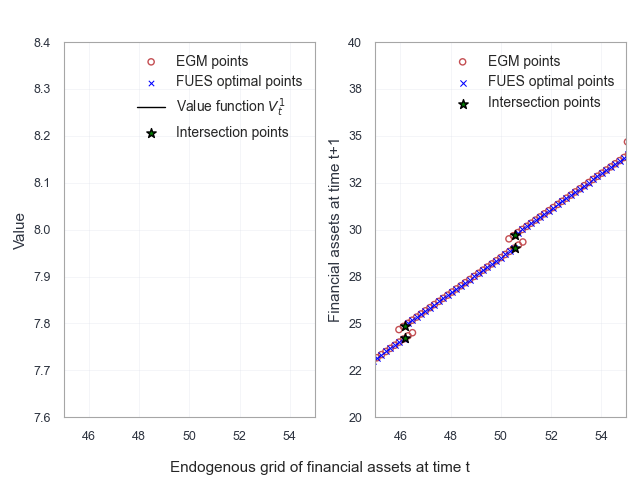

In [106]:
# ── Paper figure: EGM grids with FUES refinement (Figure 4) ──
plot_age = 17

e_grid = get_policy(nest, 'egrid', stage='work_cons')
vf_unref = get_policy(nest, 'q_hat', stage='work_cons')
c_unref = get_policy(nest, 'c_hat', stage='work_cons')
da_unref = get_policy(nest, 'da_pre_ue', stage='work_cons')

plot_egrids(plot_age, e_grid, vf_unref, c_unref, da_unref,
            model.grid_size, model, _tmpdir)
display(Image(filename=os.path.join(
    _tmpdir, f'ret_vf_aprime_all_{plot_age}_{model.grid_size}_sigma0.png'),
    width=700))

In [ ]:
# ── Interactive EGM grid plot (auto-centered on crossings, auto y-range) ──
from examples.retirement.outputs import nb_plot_egm_interactive

fig = nb_plot_egm_interactive(nest, model, age=plot_age, pad=10)
fig.show()

---

## 5. Consumption Policy Across Ages

`plot_cons_pol` shows consumption as a function of assets at three ages. The discontinuous jumps correspond to the retirement decision — agents with wealth above the threshold retire.

In [ ]:
# ── Consumption policy at multiple ages ──
from examples.retirement.outputs import nb_plot_cons_ages

fig = nb_plot_cons_ages(nest, model, ages=(10, 30, 40))
plt.show()

---

## 6. Method Comparison

All four upper-envelope methods produce identical Euler errors. The difference is speed.

In [109]:
# ── Solve with all four methods (T=50) ──
methods = ['FUES', 'DCEGM', 'RFC', 'CONSAV']
results = {}

for method in methods:
    solve_nest(SYNTAX_DIR, method=method, config_overrides={'T': 50})  # warmup
    nest_m, model_m, _ = solve_nest(
        SYNTAX_DIR, method=method, config_overrides={'T': 50})
    c_pol = get_policy(nest_m, 'c')
    ue_t, solve_t = get_timing(nest_m)
    results[method] = {
        'euler': euler(model_m, c_pol),
        'ue_ms': ue_t * 1000,
        'total_ms': solve_t * 1000,
    }

# ── Results table ──
print(f'{"Method":>8s} | {"Euler Error":>12s} | {"UE (ms)":>10s} | {"Total (ms)":>12s}')
print('-' * 50)
for m in methods:
    r = results[m]
    print(f'{m:>8s} | {r["euler"]:>12.6f} | {r["ue_ms"]:>10.3f} | {r["total_ms"]:>12.3f}')

  Method |  Euler Error |    UE (ms) |   Total (ms)
--------------------------------------------------
    FUES |    -1.368941 |      0.564 |        0.875
   DCEGM |    -1.374007 |      6.489 |        6.805
     RFC |    -1.374806 |      4.965 |        5.282
  CONSAV |    -1.373404 |      6.301 |        6.622


---

## 7. Scaling: Upper Envelope Time vs Grid Size

The key advantage of FUES: its complexity is **sub-linear** in grid size, while DCEGM scales linearly and others scale worse. We sweep grid sizes from 500 to 10,000 and plot UE time for each method.

In [110]:
# ── Scaling sweep (equal steps for visual linearity check) ──
import gc

grid_sizes = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000, 11000, 12000, 13000, 14000, 15000]
scaling = {m: [] for m in methods}

for gs in grid_sizes:
    for method in methods:
        n, _, _ = solve_nest(
            SYNTAX_DIR, method=method,
            config_overrides={'grid_size': gs, 'T': 50})
        ue, _ = get_timing(n)
        scaling[method].append(ue * 1000)
        del n
    gc.collect()
    print(f'grid_size={gs:>6d}  '
          + '  '.join(f'{m}: {scaling[m][-1]:.2f}ms' for m in methods))

grid_size=  1000  FUES: 0.26ms  DCEGM: 2.16ms  RFC: 1.65ms  CONSAV: 0.82ms
grid_size=  2000  FUES: 0.39ms  DCEGM: 4.46ms  RFC: 3.15ms  CONSAV: 2.82ms
grid_size=  3000  FUES: 0.57ms  DCEGM: 6.51ms  RFC: 4.76ms  CONSAV: 6.11ms
grid_size=  4000  FUES: 0.70ms  DCEGM: 8.47ms  RFC: 6.48ms  CONSAV: 10.91ms
grid_size=  5000  FUES: 0.91ms  DCEGM: 10.72ms  RFC: 8.48ms  CONSAV: 16.71ms
grid_size=  6000  FUES: 1.13ms  DCEGM: 12.84ms  RFC: 10.23ms  CONSAV: 23.63ms
grid_size=  7000  FUES: 1.33ms  DCEGM: 14.93ms  RFC: 12.04ms  CONSAV: 32.16ms
grid_size=  8000  FUES: 1.43ms  DCEGM: 16.98ms  RFC: 13.72ms  CONSAV: 41.87ms
grid_size=  9000  FUES: 1.67ms  DCEGM: 18.94ms  RFC: 15.93ms  CONSAV: 53.12ms
grid_size= 10000  FUES: 1.97ms  DCEGM: 21.30ms  RFC: 18.25ms  CONSAV: 65.55ms
grid_size= 11000  FUES: 2.11ms  DCEGM: 23.84ms  RFC: 19.65ms  CONSAV: 79.09ms
grid_size= 12000  FUES: 2.26ms  DCEGM: 25.54ms  RFC: 21.72ms  CONSAV: 101.04ms
grid_size= 13000  FUES: 2.62ms  DCEGM: 27.48ms  RFC: 23.03ms  CONSAV: 109.5

In [ ]:
# ── Scaling plot ──
from examples.retirement.outputs import nb_plot_scaling

fig = nb_plot_scaling(grid_sizes, scaling, methods=methods)
plt.show()

---

## Summary

- The retirement model has a **discrete-continuous** structure: the agent jointly chooses consumption (continuous) and work/retire (discrete).
- EGM inverts the Euler equation to avoid numerical optimization, but produces **suboptimal points** where future discrete choices change.
- **FUES** identifies and removes these suboptimal points via a targeted secant scan — checking for concave right turns coinciding with policy jumps.
- All four upper-envelope methods (FUES, DCEGM, RFC, CONSAV) recover the **same** upper envelope with identical Euler errors.
- FUES is the **fastest** because its complexity scales sub-linearly in grid size, whereas DCEGM scales linearly and others scale worse.

For models where policy monotonicity fails (housing, durables, non-linear taxes), FUES is the only EGM-based method that works without modification. See the [paper](https://github.com/akshayshanker/FUES) for formal proofs and additional applications.